In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Chapter 3 - Introduction to evolutionary game theory

$$M = \begin{bmatrix}
0 & \beta \\
\alpha & 0
\end{bmatrix}
$$

\begin{eqnarray}
\dot{x_2} = x_2(1-x_2)(-(\alpha+\beta)x_2+\alpha)
\end{eqnarray}

In [9]:
def x_2(x2,alpha,beta,dt):
    return (x2*(1-x2)*(-(alpha+beta)*x2+alpha))*dt + x2

In [2]:
def dx_2(x2,alpha,beta):
    return x2*(1-x2)*(-(alpha+beta)*x2+alpha)

### 3.3.1 Cancer cells dominate the system
Stable fixed points $\hat x_2 = 1$

$\alpha=0.5, \beta=-0.5$

In [3]:
alpha = 0.5
beta = -0.5
dt = 1
x20 = 0.1

In [6]:
xs = [x20]
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))

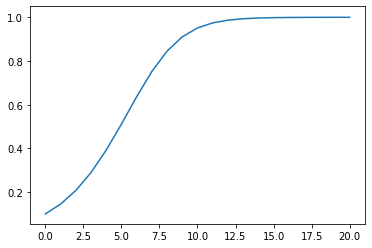

In [7]:
plt.plot(xs)
plt.ylim(None,1.05)
plt.show()

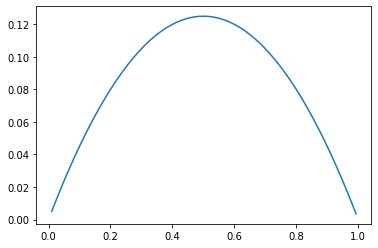

In [7]:
alpha = 0.5
beta = -0.5
dt = 0.1
x20 = 0.01

xs = [x20]
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))

plt.plot(np.array(xs), dx_2(np.array(xs),alpha,beta))
plt.show()

### 3.3.2 Healthy cells dominate the system
Stable fixed point $\hat x_2 = 0$

$\alpha=-0.5, \beta=0.5$

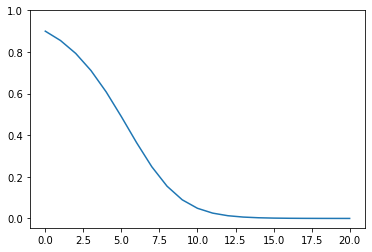

In [8]:
alpha = -0.5
beta = 0.5
dt = 1
x20 = 0.9

xs = [x20]
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))
    
plt.plot(xs)
plt.ylim(None,1)
plt.show()

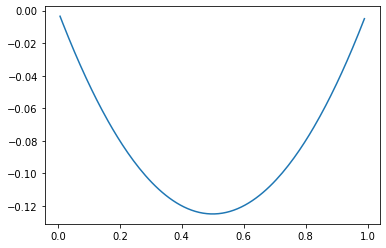

In [9]:
alpha = -0.5
beta = 0.5
dt = 0.1
x20 = 0.99

xs = [x20]
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))

plt.plot(np.array(xs), dx_2(np.array(xs),alpha,beta))
plt.show()

### 3.3.3 Stable coexistence - stable internal fixed points
Fixed points $\hat x_2 = \frac{\alpha}{\alpha+\beta}, \in (0,1)$

$\alpha=0.5, \beta=0.5$

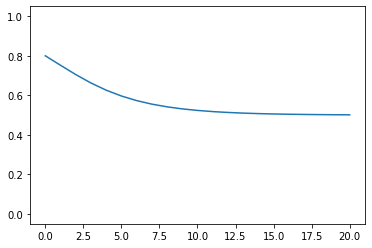

In [10]:
alpha = 0.5
beta = 0.5
dt = 1
x20 = 0.8

xs = [x20]
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))
    
plt.plot(xs)
plt.ylim(-0.05,1.05)
plt.show()

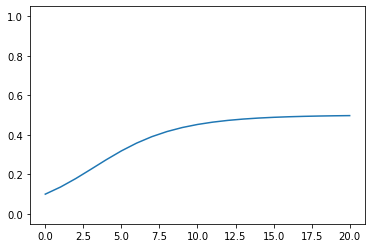

In [11]:
alpha = 0.5
beta = 0.5
dt = 1
x20 = 0.1

xs = [x20]
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))
    
plt.plot(xs)
plt.ylim(-0.05,1.05)
plt.show()

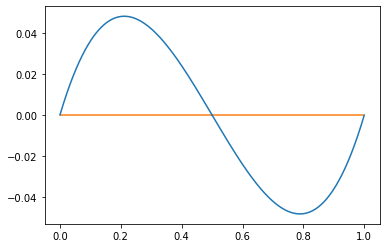

In [12]:
alpha = 0.5
beta = 0.5
dt = 0.1
x20_low = 0.0001
xsl = [x20_low]

for t in np.arange(1, 80.0001, dt):
    xsl.append(x_2(xsl[-1],alpha,beta,dt))

x20_high = 0.9999
xsh = [x20_high]

for t in np.arange(1, 80.0001, dt):
    xsh.append(x_2(xsh[-1],alpha,beta,dt))

plt.plot(np.array(xsl), dx_2(np.array(xsl),alpha,beta),'-C0')
plt.plot(np.array(xsh), dx_2(np.array(xsh),alpha,beta),'-C0')
plt.hlines(0,0,1,'tab:orange')
plt.show()

### 3.3.3 Unstable coexistence - unstable internal fixed points
Fixed points $\hat x_2 = \frac{\alpha}{\alpha+\beta}, \in (0,1)$

$\alpha=-0.5, \beta=-0.5$

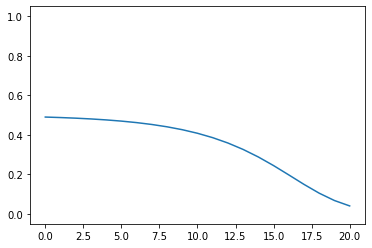

In [13]:
alpha = -0.5
beta = -0.5
dt = 1
x20 = 0.49

xs = [x20]
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))
    
plt.plot(xs)
plt.ylim(-0.05,1.05)
plt.show()

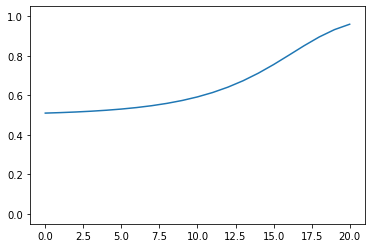

In [14]:
alpha = -0.5
beta = -0.5
dt = 1
x20 = 0.51

xs = [x20]
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))
    
plt.plot(xs)
plt.ylim(-0.05,1.05)
plt.show()

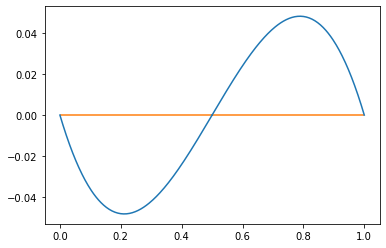

In [15]:
alpha = -0.5
beta = -0.5
dt = 0.1
x20_low = 0.4999
xsl = [x20_low]

for t in np.arange(1, 80.0001, dt):
    xsl.append(x_2(xsl[-1],alpha,beta,dt))

x20_high = 0.5001
xsh = [x20_high]

for t in np.arange(1, 80.0001, dt):
    xsh.append(x_2(xsh[-1],alpha,beta,dt))

plt.plot(np.array(xsl), dx_2(np.array(xsl),alpha,beta),'-C0')
plt.plot(np.array(xsh), dx_2(np.array(xsh),alpha,beta),'-C0')
plt.hlines(0,0,1,'tab:orange')
plt.show()

## Chapter 4 - Models with environmental feedback

#### Section in Weitz (2016): "A Model of replicator dynamics with feed-back evolving games"

### 4.1  Tipping point model

$$M 
= 
(1-n)\begin{bmatrix}
0 & \beta \\
-\alpha & 0
\end{bmatrix}
+
n\begin{bmatrix}
0 & -\beta \\
\alpha & 0
\end{bmatrix}
=
\begin{bmatrix}
0 & \beta-2n\beta \\
-\alpha+2n\alpha & 0
\end{bmatrix}
$$

\begin{eqnarray}
\dot{n} &=& \epsilon n(1-n)(\theta x_1- x_2) = \epsilon n(1-n)(\theta (1-x_2)- x_2) = \epsilon n(1-n)(\theta - (1+\theta)x_2)\\
\dot{x_2} &=& x_2(1-x_2)((\beta-\alpha)x_2+\alpha)(2n-1)
\end{eqnarray}

In [16]:
def x_2tpm(x2,alpha,beta,n,dt):
    return ((x2*(1-x2)*((beta-alpha)*x2+alpha))*(2*n-1))*dt + x2

def nfunc(n,eps,x2,theta,dt):
    return (eps*n*(1-n)*(theta*(1-x2)-x2))*dt + n

$\theta = 1, \alpha = 1, \beta = 0.7, \epsilon = 0.01$

/Users/guillermo/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


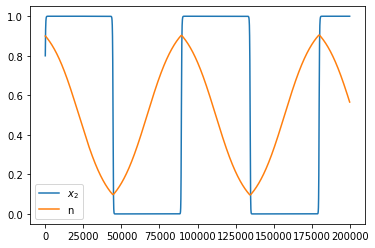

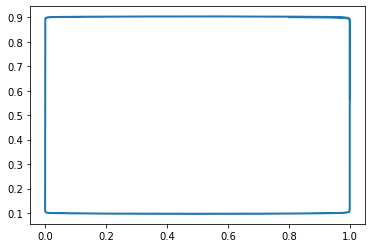

In [17]:
theta = 1
alpha = 1
beta = 0.7
eps = 0.01

dt = 0.01
x20 = 0.8
n0 = 0.9

xs = [x20]
ns = [n0]

for t in np.arange(1, 2000.0001, dt):
    xs.append(x_2tpm(xs[-1],alpha,beta,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,xs[-2],theta,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

plt.plot(xs,ns)
plt.show()

$\theta = 2, \alpha = 0.2, \beta = 0.7, \epsilon = 0.1$

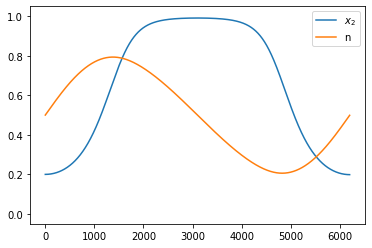

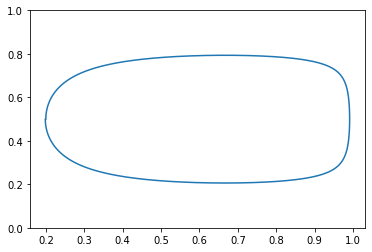

In [18]:
theta = 2
alpha = 0.2
beta = 0.7
eps = 0.1

dt = 0.01
x20 = 0.2
n0 = 0.5

xs = [x20]
ns = [n0]

for t in np.arange(1, 63.0001, dt):
    xs.append(x_2tpm(xs[-1],alpha,beta,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,xs[-2],theta,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

plt.plot(xs,ns)
plt.ylim(0,1)
plt.show()

### 4.2 Tipping point model with general matrices

#### Section in Weitz (2016): "Generalized conditions for an oscillating tragedy of the commons"

$$M 
= 
(1-n)\begin{bmatrix}
0 & \beta_0 \\
-\alpha_0 & 0
\end{bmatrix}
+
n\begin{bmatrix}
0 & -\beta_1 \\
\alpha_1 & 0
\end{bmatrix}
=
\begin{bmatrix}
0 & \beta_0-n\beta_0-n\beta_1 \\
-\alpha_0+n\alpha_0+n\alpha_1 & 0
\end{bmatrix}
$$

\begin{eqnarray}
\dot{n} &=& \epsilon n(1-n)(\theta x_1- x_2) = \epsilon n(1-n)(\theta (1-x_2)- x_2)\\
\dot{x_2} &=& x_2(1-x_2) \left( (n-1)\alpha_0+n\alpha_1-x_2((\alpha_0-\beta_0)(n-1)+(\alpha_1-\beta_1)n) \right)
\end{eqnarray}

In [19]:
def x_2tpmg(x2,alpha0,beta0,alpha1,beta1,n,dt):
    return (x2*(1-x2)*((n-1)*alpha0+n*alpha1-x2*((alpha0-beta0)*(n-1)+(alpha1-beta1)*n)))*dt + x2

In [20]:
def nfunc(n,eps,x2,theta,dt):
    return (eps*n*(1-n)*(theta*(1-x2)-x2))*dt + n

#### Asymptotically stable, Heteroclinic cycle

$\theta = 2, \alpha_0 = 1.5, \beta_0 = 0.25, \alpha_1 = 0.5, \beta_1 = 0.25, \epsilon = 0.1$

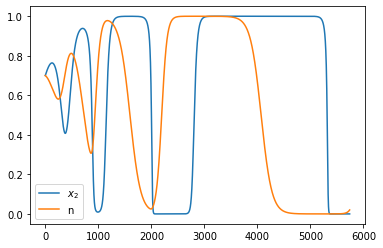

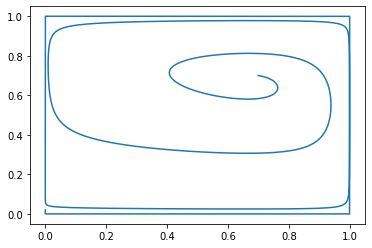

In [21]:
theta = 2
alpha0 = 1.5
beta0 = 0.25
alpha1 = 0.5
beta1 = 0.25
eps = 0.1

dt = 0.1
x20 = 0.7
n0 = 0.7

xs = [x20]
ns = [n0]

for t in np.arange(1, 575.0001, dt):
    xs.append(x_2tpmg(xs[-1],alpha0,beta0,alpha1,beta1,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,xs[-2],theta,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

plt.plot(xs,ns)
plt.ylim(-0.05,1.05)
plt.show()

#### Attracting fixed point

$\theta = 2, \alpha_0 = 0.75, \beta_0 = 0.5, \alpha_1 = 1.5, \beta_1 = 0.5, \epsilon = 0.1$

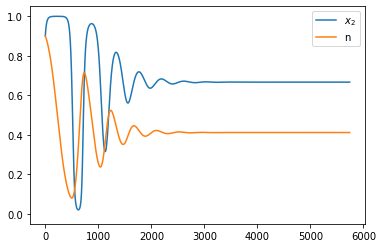

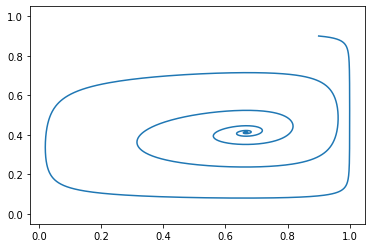

In [22]:
theta = 2
alpha0 = 0.75
beta0 = 0.5
alpha1 = 1.5
beta1 = 0.5
eps = 0.1

dt = 0.1
x20 = 0.9
n0 = 0.9

xs = [x20]
ns = [n0]

for t in np.arange(1, 575.0001, dt):
    xs.append(x_2tpmg(xs[-1],alpha0,beta0,alpha1,beta1,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,xs[-2],theta,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

plt.plot(xs,ns)
plt.ylim(-0.05,1.05)
plt.show()

#### Different timescales $\epsilon$

$\theta=2, \alpha_0=1.5, \beta_0=1, \alpha_1=3, \beta_1=1, \epsilon = 0.1$

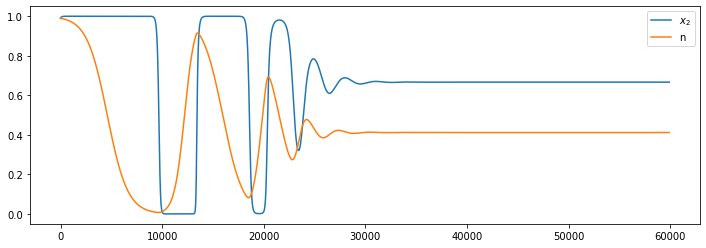

In [23]:
theta = 2
alpha0 = 1.5
beta0 = 1
alpha1 = 3
beta1 = 1
eps = 0.1

dt = 0.01
x20 = 0.99
n0 = 0.99

xs = [x20]
ns = [n0]

for t in np.arange(1, 600.0001, dt):
    xs.append(x_2tpmg(xs[-1],alpha0,beta0,alpha1,beta1,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,xs[-2],theta,dt))

plt.figure(figsize=(12, 4))
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

$\theta=2, \alpha_0=1.5, \beta_0=1, \alpha_1=3, \beta_1=1, \epsilon = 0.05$

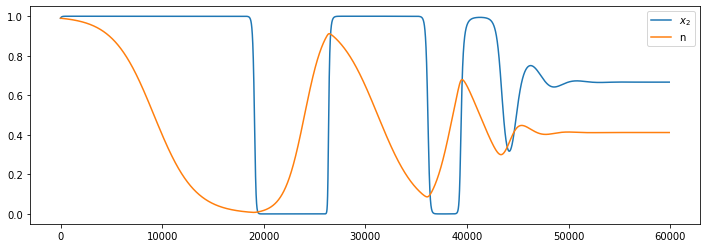

In [24]:
theta = 2
alpha0 = 1.5
beta0 = 1
alpha1 = 3
beta1 = 1
eps = 0.05

dt = 0.01
x20 = 0.99
n0 = 0.99

xs = [x20]
ns = [n0]

for t in np.arange(1, 600.0001, dt):
    xs.append(x_2tpmg(xs[-1],alpha0,beta0,alpha1,beta1,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,xs[-2],theta,dt))

plt.figure(figsize=(12, 4))
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

$\theta=2, \alpha_0=1.5, \beta_0=0.25, \alpha_1=0.5, \beta_1=0.25, \epsilon=0.1$

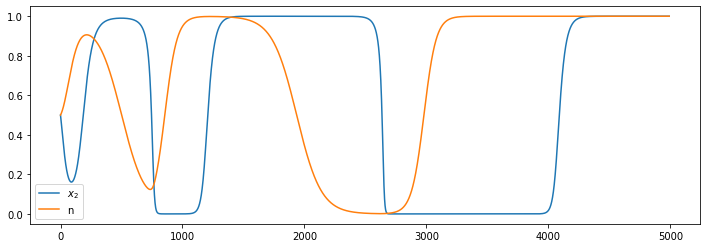

In [25]:
theta = 2
alpha0 = 1.5
beta0 = 0.25
alpha1 = 0.5
beta1 = 0.25
eps = 0.1

dt = 0.1
x20 = 0.5
n0 = 0.5

xs = [x20]
ns = [n0]

for t in np.arange(1, 500.0001, dt):
    xs.append(x_2tpmg(xs[-1],alpha0,beta0,alpha1,beta1,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,xs[-2],theta,dt))

plt.figure(figsize=(12, 4))
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

$\theta=2, \alpha_0=1.5, \beta_0=0.25, \alpha_1=0.5, \beta_1=0.25, \epsilon=0.05$

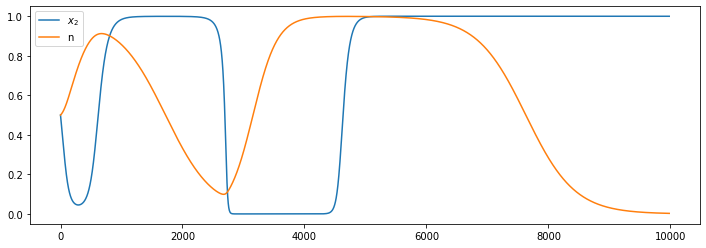

In [26]:
theta = 2
alpha0 = 1.5
beta0 = 0.25
alpha1 = 0.5
beta1 = 0.25
eps = 0.05

dt = 0.05
x20 = 0.5
n0 = 0.5

xs = [x20]
ns = [n0]

for t in np.arange(1, 500.0001, dt):
    xs.append(x_2tpmg(xs[-1],alpha0,beta0,alpha1,beta1,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,xs[-2],theta,dt))

plt.figure(figsize=(12, 4))   
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

### 4.4 Decreasing resources

From Tilman (2020), section "Eco-evolutionary games with self-renewing and decaying resources", part of decaying resources

\begin{equation}
\dot{n} = \epsilon \gamma (1-x_2-n)
\end{equation}

In [11]:
def x_2tpmg(x2,alpha0,beta0,alpha1,beta1,n,dt):
    return (x2*(1-x2)*((n-1)*alpha0+n*alpha1-x2*((alpha0-beta0)*(n-1)+(alpha1-beta1)*n)))*dt + x2

In [12]:
def nfunc(n,eps,gamma,x2,dt):
    return (eps*gamma*(1-x2-n))*dt + n

$\gamma=1, \alpha_0=0.6, \beta_0=0.3, \alpha_1=0.9, \beta_1=0.3, \epsilon=0.001$

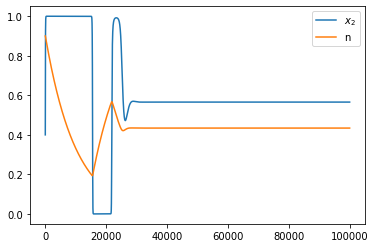

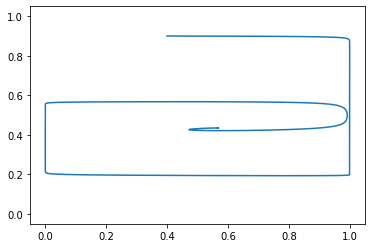

In [13]:
gamma = 1
alpha0 = 0.6
beta0 = 0.3
alpha1 = 0.9
beta1 = 0.3
eps = 0.001

dt = 0.1
x20 = 0.4
n0 = 0.9

xs = [x20]
ns = [n0]

for t in np.arange(1, 10000.0001, dt):
    xs.append(x_2tpmg(xs[-1],alpha0,beta0,alpha1,beta1,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,gamma,xs[-2],dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

plt.plot(xs,ns)
plt.ylim(-0.05,1.05)
plt.show()

$\gamma=2, \alpha_0=3, \beta_0=1, \alpha_1=2, \beta_1=1, \epsilon=0.001$

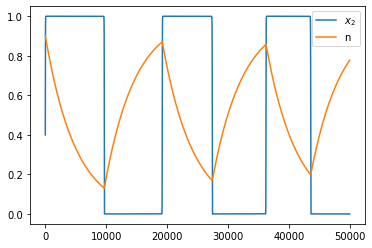

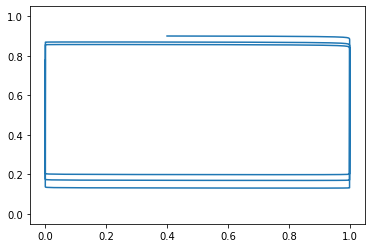

In [14]:
gamma = 2
alpha0 = 3
beta0 = 1
alpha1 = 2
beta1 = 1
eps = 0.001

dt = 0.1
x20 = 0.4
n0 = 0.9

xs = [x20]
ns = [n0]

for t in np.arange(1, 5000.0001, dt):
    xs.append(x_2tpmg(xs[-1],alpha0,beta0,alpha1,beta1,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,gamma,xs[-2],dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

plt.plot(xs,ns)
plt.ylim(-0.05,1.05)
plt.show()

### VARIATION of TILMAN's

In [33]:
def nfunc(n,eps,gamma,x2,dt):
    return (eps*gamma*(x2-n))*dt + n

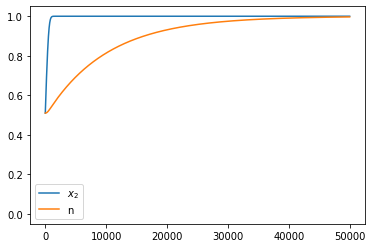

'\nplt.plot(xs,ns)\nplt.ylim(-0.05,1.05)\nplt.show()\n'

In [39]:
gamma = 1
alpha0 = 3
beta0 = 1
alpha1 = 3
beta1 = 1
eps = 0.001

dt = 0.1
x20 = 0.51
n0 = 0.51

xs = [x20]
ns = [n0]

for t in np.arange(1, 5000.0001, dt):
    xs.append(x_2tpmg(xs[-1],alpha0,beta0,alpha1,beta1,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,gamma,xs[-2],dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

"""
plt.plot(xs,ns)
plt.ylim(-0.05,1.05)
plt.show()
"""

#### Different timescales $\epsilon$

$\gamma=2, \alpha_0=3, \beta_0=1, \alpha_1=2, \beta_1=1, \epsilon=0.1, \epsilon=0.01$

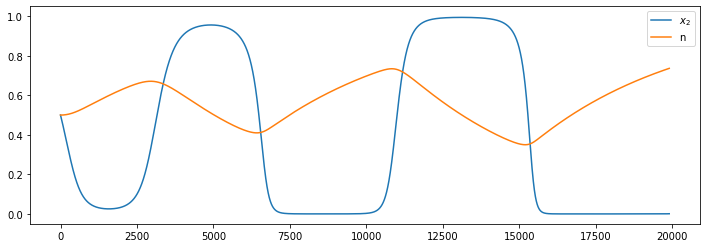

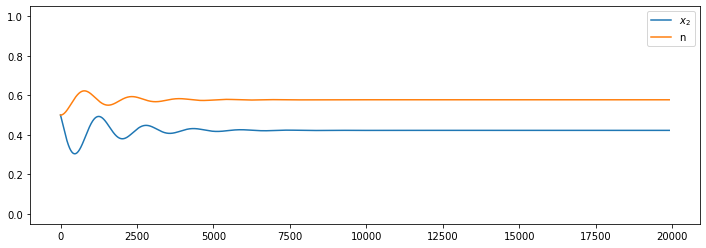

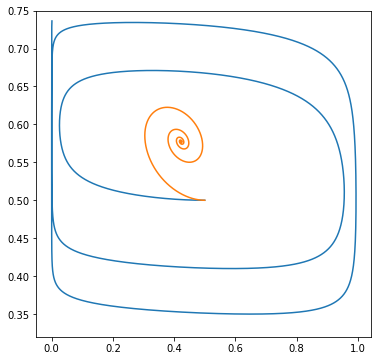

In [31]:
gamma = 2
alpha0 = 3
beta0 = 1
alpha1 = 2
beta1 = 1
eps = [0.1, 0.01]

dt = 0.01
x20 = 0.5
n0 = 0.5

xsl = [x20]
nsl = [n0]

for t in np.arange(1, 200.0001, dt):
    xsl.append(x_2tpmg(xsl[-1],alpha0,beta0,alpha1,beta1,nsl[-1],dt))
    nsl.append(nfunc(nsl[-1],eps[0],gamma,xsl[-2],dt))

xsh = [x20]
nsh = [n0]

for t in np.arange(1, 200.0001, dt):
    xsh.append(x_2tpmg(xsh[-1],alpha0,beta0,alpha1,beta1,nsh[-1],dt))
    nsh.append(nfunc(nsh[-1],eps[1],gamma,xsh[-2],dt))

    
plt.figure(figsize=(12, 4))
plt.plot(xsh, label='$x_2$')
plt.plot(nsh, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(xsl, label='$x_2$')
plt.plot(nsl, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(xsh,nsh,'-C0')
plt.plot(xsl,nsl,'tab:orange')
plt.ylim(0.32,0.75)
plt.show()

### Chapter 5 - Results

#### 5.1 Model

$$M
=
(1-f(n))M_h + f(n)M_s
= 
(1-f(n))\begin{bmatrix}
0 & \beta \\
-\alpha & 0
\end{bmatrix}
+
f(n)\begin{bmatrix}
0 & -\beta \\
\alpha & 0
\end{bmatrix}
$$

\begin{eqnarray}
f(n) &=& \frac{n}{n+k} \\
\dot{x_2} &=& x_2(1-x_2)(-(\alpha(n)+\beta(n))x_2+\alpha(n)) \\
\dot{n} &=& \epsilon x_2 - \mu n
\end{eqnarray}

In [2]:
def switch(k,n):
    return n/(n+k)

def x_2(x2,alphan,betan,dt):
    return (x2*(1-x2)*(-(alphan+betan)*x2+alphan))*dt + x2

def nfunc(n,x2,eps,mu,dt):
    return (eps*x2 - mu*n)*dt + n

def Mhfunc(alpha,beta):
    return np.array([[0, beta],
                     [-alpha, 0]])

def Msfunc(alpha,beta):
    return np.array([[0, -beta],
                     [alpha, 0]])

def Mn(sw,Mh,Ms):
    return (1-sw)*Mh + sw*Ms

#### 5.2 Hostile environment

$\alpha=0.5, \beta=0.6, \epsilon=0.16, \mu=0.02, k=0.1$

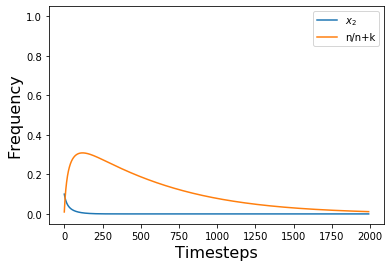

In [42]:
alpha = 0.5
beta = 0.6
eps = 0.16
mu = 0.02
k = 0.1

dt = 0.1
x20 = 0.1
n0 = 0.001

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 200.0001, dt):
    ns.append(nfunc(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(switch(k,ns[-1]), Mh, Ms)
    alphan = M[1,0]
    betan = M[0,1]
    xs.append(x_2(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(switch(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

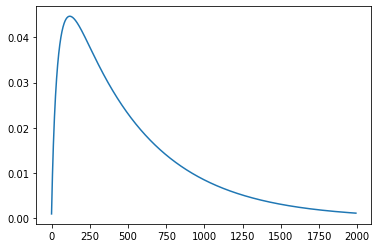

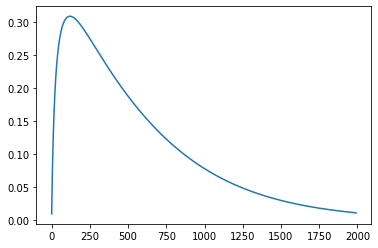

In [48]:
plt.plot(ns)
plt.show()

plt.plot(switch(k,np.array(ns)))
plt.show()

$\alpha=0.5, \beta=0.6, \epsilon=0.23, \mu=0.02, k=0.1$

In [1]:
alpha = 0.5
beta = 0.6
eps = 0.23
mu = 0.02
k = 0.1

dt = 0.1
x20 = 0.1
n0 = 0.001

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 200.0001, dt):
    ns.append(nfunc(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(switch(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    betan = M[0,1]
    xs.append(x_2(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(switch(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

NameError: name 'Mhfunc' is not defined

In [4]:
ns[-1]

10.890469415448472

In [7]:
ns[-1] / (ns[-1] + k)

0.9909012075626691

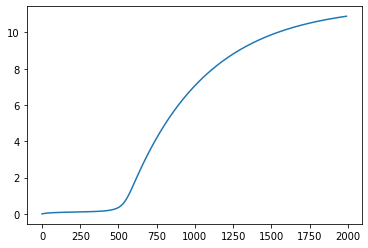

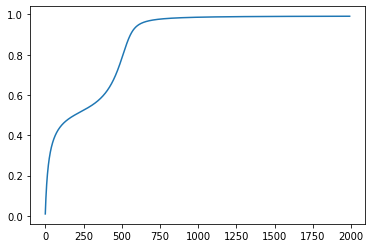

In [50]:
plt.plot(ns)
plt.show()

plt.plot(switch(k,np.array(ns)))
plt.show()

#### 5.3 Stable environment

$$M
=
(1-f(n))M_h + f(n)M_s
= 
(1-f(n))\begin{bmatrix}
0 & \beta \\
\alpha & 0
\end{bmatrix}
+
f(n)\begin{bmatrix}
0 & -\beta \\
\alpha & 0
\end{bmatrix}
$$

In [51]:
def Mhfunc(alpha,beta):
    return np.array([[0, beta],
                     [alpha, 0]])

$\alpha=0.1, \beta=0.9, \epsilon=0.04, \mu=0.02, k=2$

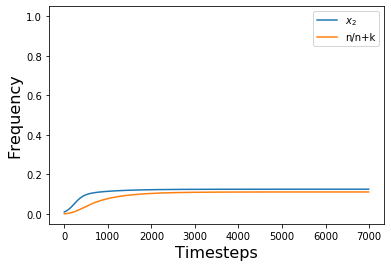

In [52]:
alpha = 0.1
beta = 0.9
eps = 0.04
mu = 0.02
k = 2

dt = 0.1
x20 = 0.01
n0 = 0.001

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 700.0001, dt):
    ns.append(nfunc(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(switch(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    betan = M[0,1]
    xs.append(x_2(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(switch(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

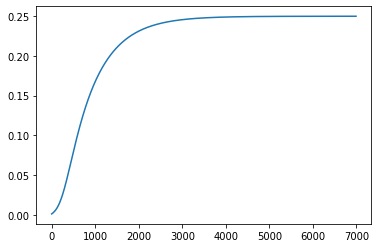

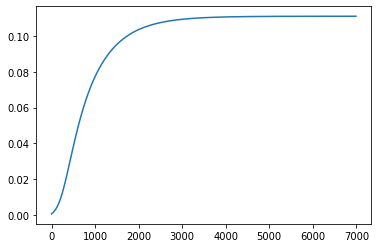

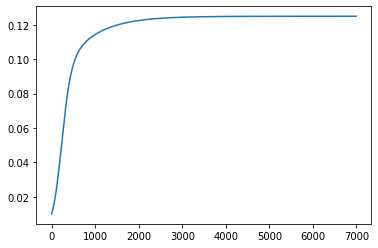

In [54]:
plt.plot(ns)
plt.show()

plt.plot(switch(k,np.array(ns)))
plt.show()

plt.plot(xs)
plt.show()

$\alpha=0.1, \beta=0.9, \epsilon=0.09, \mu=0.02, k=2$

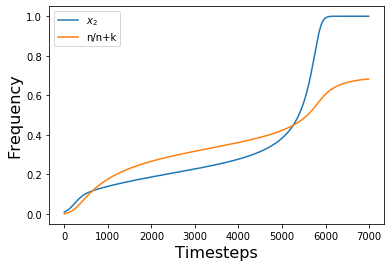

In [23]:
alpha = 0.1
beta = 0.9
eps = 0.09
mu = 0.02
k = 2

dt = 0.1
x20 = 0.01
n0 = 0.001

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 700.0001, dt):
    ns.append(nfunc(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(switch(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    betan = M[0,1]
    xs.append(x_2(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(switch(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

In [24]:
eps/mu

4.5

### Chapter 6 - Mathematical analysis and methods

#### 6.1 Tipping point model with a stable matrix

$$M 
= 
(1-n)\begin{bmatrix}
0 & \beta \\
\alpha & 0
\end{bmatrix}
+
n\begin{bmatrix}
0 & -\beta \\
\alpha & 0
\end{bmatrix}
=
\begin{bmatrix}
0 & \beta -2n\beta \\
\alpha & 0
\end{bmatrix}
$$

\begin{eqnarray}
\dot{n} = \epsilon n(1-n)(-1+(1+\theta)x_2) \\
\dot{x_2} = x_2(1-x_2)(((2n-1)\beta-\alpha)x_2+\alpha)
\end{eqnarray}

In [55]:
def x_2t(x2,alpha,beta,n,dt):
    return (x2*(1-x2)*(((2*n-1)*beta-alpha)*x2+alpha))*dt + x2

def nfunc(n,eps,x2,theta,dt):
    return (eps*n*(1-n)*(-1+(1+theta)*x2))*dt + n

$\theta=1, \alpha=0.4, \beta=0.8, \epsilon=0.1$

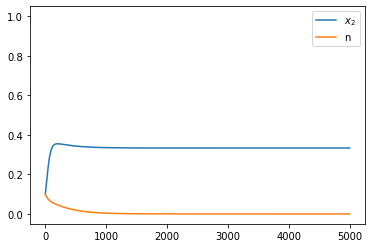

In [56]:
theta = 1
alpha = 0.4
beta = 0.8
eps = 0.1

dt = 0.1
x20 = 0.1
n0 = 0.1

xs = [x20]
ns = [n0]

for t in np.arange(1, 500.0001, dt):
    xs.append(x_2t(xs[-1],alpha,beta,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,xs[-2],theta,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

$\theta=2.1, \alpha=0.4, \beta=0.8, \epsilon=0.1$

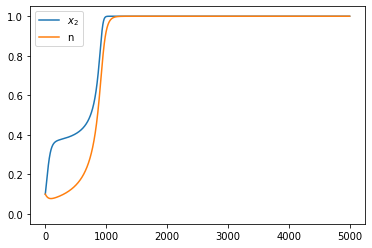

In [59]:
theta = 2.1
alpha = 0.4
beta = 0.8
eps = 0.1

dt = 0.1
x20 = 0.1
n0 = 0.1

xs = [x20]
ns = [n0]

for t in np.arange(1, 500.0001, dt):
    xs.append(x_2t(xs[-1],alpha,beta,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,xs[-2],theta,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

#### 6.2 Stable and unstable coexistence

$$M 
= 
(1-n)\begin{bmatrix}
0 & \beta \\
\alpha & 0
\end{bmatrix}
+
n\begin{bmatrix}
0 & -\beta \\
-\alpha & 0
\end{bmatrix}
=
\begin{bmatrix}
0 & \beta-2n\beta \\
\alpha-2n\alpha & 0
\end{bmatrix}
$$

\begin{eqnarray}
\dot{n} = \epsilon n(1-n)(-1+(1+\theta)x_2) \\
\dot{x_2} = x_2(1-x_2)(1-2n)(-(\alpha+\beta)x_2+\alpha)
\end{eqnarray}

In [72]:
def x_2t(x2,alpha,beta,n,dt):
    return (x2*(1-x2)*(1-2*n)*(-(alpha+beta)*x2+alpha))*dt + x2

def nfunc(n,eps,x2,theta,dt):
    return (eps*n*(1-n)*(-1+(1+theta)*x2))*dt + n

$\theta=1, \alpha=0.4, \beta=0.8, \epsilon=0.1$

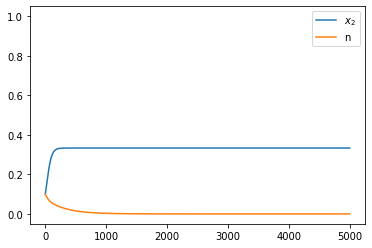

In [73]:
theta = 1
alpha = 0.4
beta = 0.8
eps = 0.1

dt = 0.1
x20 = 0.1
n0 = 0.1

xs = [x20]
ns = [n0]

for t in np.arange(1, 500.0001, dt):
    xs.append(x_2t(xs[-1],alpha,beta,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,xs[-2],theta,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

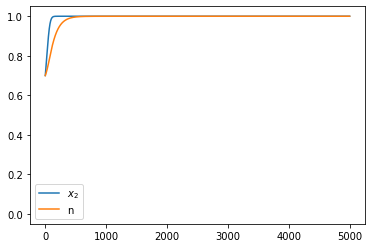

In [43]:
theta = 1
alpha = 0.4
beta = 0.8
eps = 0.1

dt = 0.1
x20 = 0.7
n0 = 0.7

xs = [x20]
ns = [n0]

for t in np.arange(1, 500.0001, dt):
    xs.append(x_2t(xs[-1],alpha,beta,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,xs[-2],theta,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

$\theta=3, \alpha=0.4, \beta=0.8, \epsilon=0.1$

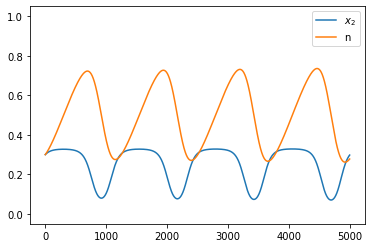

In [44]:
theta = 3
alpha = 0.4
beta = 0.8
eps = 0.1

dt = 0.1
x20 = 0.3
n0 = 0.3

xs = [x20]
ns = [n0]

for t in np.arange(1, 500.0001, dt):
    xs.append(x_2t(xs[-1],alpha,beta,ns[-1],dt))
    ns.append(nfunc(ns[-1],eps,xs[-2],theta,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(ns, label='n')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

#### 6.3 The new model without regeneration factor, $\mu = 0$

#### 6.3.2 Hostile environment

$$M
=
(1-f(n))M_h + f(n)M_s
= 
(1-f(n))\begin{bmatrix}
0 & \beta \\
-\alpha & 0
\end{bmatrix}
+
f(n)\begin{bmatrix}
0 & -\beta \\
\alpha & 0
\end{bmatrix}
$$

\begin{eqnarray}
f(n) &=& \frac{n}{n+k} \\
\dot{x_2} &=& x_2(1-x_2)(-(\beta(n)+\alpha(n))x_2+\alpha(n)) \\
\dot{n} &=& \epsilon x_2 - \mu n
\end{eqnarray}

In [45]:
def switch(k,n):
    return n/(k+n)

def x_2(x2,alphan,betan,dt):
    return (x2*(1-x2)*(-(alphan+betan)*x2+alphan))*dt + x2

def nfunc(n,x2,eps,mu,dt):
    return (eps*x2 - mu*n)*dt + n

def Mhfunc(alpha,beta):
    return np.array([[0, beta],
                     [-alpha, 0]])

def Msfunc(alpha,beta):
    return np.array([[0, -beta],
                     [alpha, 0]])

def Mn(sw,Mh,Ms):
    return (1-sw)*Mh + sw*Ms

$\alpha=0.1, \beta=0.9, \epsilon=0.1, \mu=0, k=0.4$

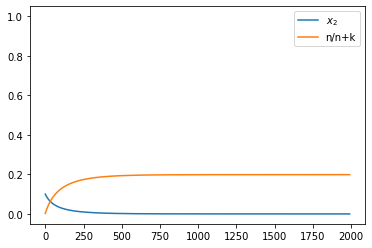

In [46]:
alpha = 0.1
beta = 0.9
eps = 0.1
mu = 0.0
k = 0.4

dt = 0.1
x20 = 0.1
n0 = 0.001

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 200.0001, dt):
    ns.append(nfunc(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(switch(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    betan = M[0,1]
    xs.append(x_2(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(switch(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

$\alpha=0.1, \beta=0.9, \epsilon=0.3, \mu=0, k=0.4$

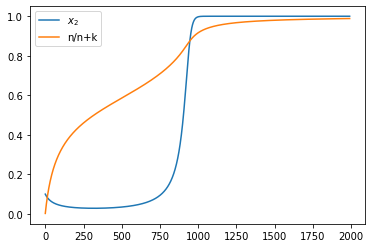

In [47]:
alpha = 0.1
beta = 0.9
eps = 0.3
mu = 0.0
k = 0.4

dt = 0.1
x20 = 0.1
n0 = 0.001

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 200.0001, dt):
    ns.append(nfunc(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(switch(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    betan = M[0,1]
    xs.append(x_2(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(switch(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.ylim(-0.05,1.05)
plt.show()

#### 6.3.3 Healthy matrix with stable coexistence

$$M
=
(1-f(n))M_h + f(n)M_s
= 
(1-f(n))\begin{bmatrix}
0 & \beta \\
\alpha & 0
\end{bmatrix}
+
f(n)\begin{bmatrix}
0 & -\beta \\
\alpha & 0
\end{bmatrix}
$$

In [48]:
def Mhfunc(alpha,beta):
    return np.array([[0, beta],
                     [alpha, 0]])

$\alpha=0.1, \beta=0.8, \epsilon=0.001, \mu=0, k=[0.25, 0.5, 0.75, 1.0]$

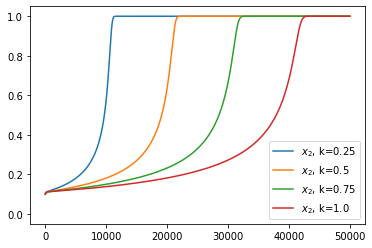

In [49]:
alpha = 0.1
beta = 0.8
eps = 0.001
mu = 0.0
ks = [0.25, 0.5, 0.75, 1.0]

dt = 0.1
x20 = 0.1
n0 = 0.001

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

for i in range(0,len(ks)):
    xs = [x20]
    ns = [n0]
    for t in np.arange(1, 5000.0001, dt):
        ns.append(nfunc(ns[-1],xs[-1],eps,mu,dt))
        M = Mn(switch(ks[i],ns[-1]), Mh,Ms)
        alphan = M[1,0]
        betan = M[0,1]
        xs.append(x_2(xs[-1],alphan,betan,dt))
    plt.plot(xs, label=f'$x_2$, k={ks[i]}')
    
#plt.plot(switch(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend(loc='best')
plt.ylim(-0.05,1.05)
plt.show()